# Etapa 1: TÍTULO E OBJECTIVO
### Título do Projecto:
- **Prediçao da idade de Estrelas com Dados Fotometricos e Astrométricos do Catologo GAIA**

### Objectivo Geral:
- **Investigar como as propriedades observacionais de estrelas, como parale, temperatura, cor e magnetude se relacionam com sua idade, e desenvolver um modelo preditivo para estimar a idade estelar a partir de dados fornecidos pelo catalogo GAIA.**

### Objectivos Especificos:
- **Colectar um Subconjunto de dados do Catalogo GAIA contendo estrelas com medidas confiaveis;**
- **Analisar as corelacoes entre característcas observaveis e dade estelar**
- **Treinar um modelo de aprenizado de maquina para prever a idade com base nessas variaveis'**
- **Avaliar o desempenho preditivo e interpretar os fatores fisicos mais relevamntes para o envelhimento estelar**



# Etapa 2: DESCRIÇÃO DO CONJUNTO DE DADOS
**Para este projeto, será utilizado o catálogo astrométrico da missão GAIA, disponibilizado pela Agência Espacial Europeia (ESA). O GAIA é um observatório espacial dedicado à medição precisa das posições, distâncias, movimentos e propriedades físicas de mais de 1 bilhão de estrelas na Via Láctea**

A partir desse catalogo, serao extraidas **estrelas com dados completos e confiaveis**, contendo os seguintes parametros:
* palaxe (`pallax`): usada para calcular a distancia da estrela á terra
* Magnetude aparente G (`phot_g_mean_mag`): brilho observado no filtro G do GAIA;
* Cor esterlar (`bp_rp`): diferenca entre a magnetude nos filtros(azul) e RP (vermelho), que infica a temperatura Superficial;
* Tenperatura efetiva (`teff_val`): temperatura superficial da estrla, medida em Kelvin
* luminosidade estimada(`lum_val`): qual brilhante a estrela realmente é, considerando a sua distancia;
* Metallicidade(`feh`): quantidade relativa de elemtentos mais pesados que o hidrogenio 


**Como o catologo GAIA nao fornece directamente directamente a idade  das estrelas, sera necessario fazer um cruzamento entre os dados com teoricos de evolucao estelar, como os modelos MIST ou BASTI, que estimam a idade com base na posicao da estrela no diagrama Hertzsprung-Russell(diagrama cor magnitude)**

**Alguns Cruzamentos ja foram feitos pir Projectos Complementares ao GAIA, como o catologo StarHorse ou o Apsis da Propria ESA, que disponibilizam idades estimadas com base em modelos fisicos**

### Etapa 3: LIMPEZA E PRÉ-PROCESSAMENTO DOS DADOS

### Passo 1: Importacoes das bibliotecas

In [2]:
# Instala astroquery, necessário para acessar dados do GAIA pela internet
!pip install astroquery --quiet

In [1]:
# Importação de bibliotecas essenciais
import pandas as pd                 # Para manipulação de tabelas (dataframes)
import numpy as np                 # Para cálculos matemáticos
import matplotlib.pyplot as plt    # Para gráficos
#from astroquery.gaia import Gaia   # Para consultar o catálogo GAIA

# Ativa visualizações mais bonitas para gráficos 
%matplotlib inline

### Passo 2: Carregar o dataset do GAIA 

In [2]:
# Vamos pegar apenas estrelas com dados de paralaxe, magnitude, cor, temperatura, luminosidade e idade estimada

df = pd.read_csv('data/dataGaia2.csv')  #Carregando o dataset baixado pelo GAIA

In [3]:
df.info() # Procurando as colunas necessarisa

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626016 entries, 0 to 626015
Data columns (total 50 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  626016 non-null  int64  
 1   RA_ICRS     626016 non-null  float64
 2   DE_ICRS     626016 non-null  float64
 3   Source      626016 non-null  int64  
 4   e_RA_ICRS   626016 non-null  float64
 5   e_DE_ICRS   626016 non-null  float64
 6   Plx         626016 non-null  float64
 7   e_Plx       626016 non-null  float64
 8   PM          626016 non-null  float64
 9   pmRA        626016 non-null  float64
 10  e_pmRA      626016 non-null  float64
 11  pmDE        626016 non-null  float64
 12  e_pmDE      626016 non-null  float64
 13  RUWE        626016 non-null  float64
 14  Gmag        626015 non-null  float64
 15  e_Gmag      626015 non-null  float64
 16  BPmag       626015 non-null  float64
 17  e_BPmag     626015 non-null  float64
 18  RPmag       626016 non-null  float64
 19  e_

**Podemos perceber que o dataset contem as colunas necessarias e suficientes para o nosso estudo**

In [4]:
#Vamos exibr as primeiras linhas 
print('Visualizano as primeiras linhas do dataset')
display(df.head())

Visualizano as primeiras linhas do dataset


,Unnamed: 0,RA_ICRS,DE_ICRS,Source,e_RA_ICRS,e_DE_ICRS,Plx,e_Plx,PM,pmRA,...,Lum-Flame,Mass-Flame,Age-Flame,z-Flame,Evol,SpType-ELS,Flags-HS,EWHa,e_EWHa,f_EWHa
0,0,44.589012,2.195298,1306361548360576,0.0655,0.0612,0.2384,0.0769,2.901,2.088,...,298.485140,NaN,NaN,1.507248,NaN,O,92,0.02128,0.19309,0
1,1,35.358035,8.988813,23700286669971584,0.0658,0.0717,0.1666,0.0785,4.402,-0.242,...,292.672100,NaN,NaN,1.332909,NaN,O,92,0.02144,0.17600,0
2,2,44.450767,10.079118,27109837867995776,0.0627,0.0517,0.3544,0.0727,3.154,2.722,...,506.732800,NaN,NaN,1.582338,NaN,O,92,0.13726,0.13364,0
3,3,48.404909,15.105912,31009771252186752,0.0500,0.0421,0.5962,0.0557,2.745,2.460,...,9.055018,NaN,NaN,1.561845,NaN,O,93,0.09470,0.10548,0
4,4,57.092838,11.550927,36876009385300352,0.0521,0.0335,0.4507,0.0575,4.918,-2.851,...,311.502840,NaN,NaN,1.521734,NaN,O,92,0.08682,0.07831,0


In [3]:
#Selecionando as colunas mais importantes para o estudo

features = [
    'Teff',          # Temperatura efetiva
    'BPmag',         # Magnitude no filtro azul (cor azul)
    'RPmag',         # Magnitude no filtro vermelho
    'Gmag',          # Magnitude aparente G
    'GMAG',          # Magnitude absoluta G
    'Lum-Flame',     # Luminosidade (em L☉)
    'Mass-Flame',    # Massa (em M☉)
    'Rad-Flame',     # Raio (em R☉)
    '[Fe/H]',        # Metalicidade
    'logg'           # Gravidade superficial
]

target = 'Age-Flame' #Idade da estrrela, em bilhoes de Anos

In [4]:
#Crindo um novo DataFrame apenas com essas colunas
df_model = df[features + [target]]

In [5]:
df_model.head()  #Vefiriando as primeiras linhas do novo Dataset

,Teff,BPmag,RPmag,Gmag,GMAG,Lum-Flame,Mass-Flame,Rad-Flame,[Fe/H],logg,Age-Flame
0,18148.611,16.761435,17.134040,16.908537,0.3894,298.485140,NaN,1.7096,-0.9759,4.5728,NaN
1,17500.236,16.841173,17.193855,16.962143,0.3548,292.672100,NaN,1.8249,-1.1661,4.4948,NaN
2,19761.363,16.382404,16.429598,16.407494,0.0162,506.732800,NaN,1.9063,-0.9919,4.5526,NaN
3,19486.800,15.497600,15.672352,15.607131,0.0268,9.055018,NaN,0.2579,-0.9392,4.5211,NaN
4,18453.346,16.354900,16.384790,16.372738,0.3626,311.502840,NaN,1.7220,-0.9965,4.5807,NaN


In [9]:
df_model.info()  #Verficando as informacoes da dataset (temos 11 colunas com mais de 626016 linhas)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626016 entries, 0 to 626015
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Teff        626016 non-null  float64
 1   BPmag       626015 non-null  float64
 2   RPmag       626016 non-null  float64
 3   Gmag        626015 non-null  float64
 4   GMAG        626016 non-null  float64
 5   Lum-Flame   611293 non-null  float64
 6   Mass-Flame  590796 non-null  float64
 7   Rad-Flame   611293 non-null  float64
 8   [Fe/H]      626016 non-null  float64
 9   logg        626016 non-null  float64
 10  Age-Flame   544681 non-null  float64
dtypes: float64(11)
memory usage: 52.5 MB


In [5]:
#Verffiacando valores Ausentes
df_model.isnull().sum() 

#percebe-se que temos valores ausentes.

Teff              0
BPmag             1
RPmag             0
Gmag              1
GMAG              0
Lum-Flame     14723
Mass-Flame    35220
Rad-Flame     14723
[Fe/H]            0
logg              0
Age-Flame     81335
dtype: int64

In [6]:
#Fazendo a limpeza dos valores ausentes(NaNs)
df_model = df_model.dropna()

#df_model.info()
#Agora temos um novo df ja tratado sem esses valores

In [7]:
# Exibindo estatisticas basicas para entender a escala dos dados
print('Estatistica descritiva do novo dataset limpo')
display(df_model.describe())

Estatistica descritiva do novo dataset limpo


,Teff,BPmag,RPmag,Gmag,GMAG,Lum-Flame,Mass-Flame,Rad-Flame,[Fe/H],logg,Age-Flame
count,544680.000000,544680.000000,544680.000000,544680.000000,544680.000000,544680.000000,544680.000000,544680.000000,544680.000000,544680.000000,544680.000000
mean,6205.688385,14.217690,12.854826,13.563267,2.600588,83.900576,1.677107,7.362512,-0.336745,3.706011,3.776441
std,1816.081032,1.846195,1.452883,1.587541,2.637643,274.138274,0.792226,17.957926,0.413831,0.928976,4.139874
min,3039.229700,3.418268,2.910680,3.120973,-6.998500,0.034732,0.500000,0.453800,-4.143400,-0.475500,0.200000
25%,5064.425275,13.196011,12.000165,12.638552,0.708000,1.772021,1.021000,1.278800,-0.539200,3.515200,0.524000
50%,5798.538600,14.601432,13.276073,14.010746,2.426100,8.136774,1.541000,2.001600,-0.285600,4.010500,1.448000
75%,7197.936450,15.403983,13.916041,14.680663,4.118300,46.346430,2.267000,3.806100,-0.082200,4.244200,6.629000
max,11760.905000,21.326849,17.111986,17.643257,9.963000,3499.719500,3.816000,181.063300,0.800000,4.942500,13.500000


In [8]:
# Separando os dados em variáveis de entrada (X) e saída (y)
X = df_model[features].values
y = df_model[target].values  #idade estimada das estrelas

In [9]:
# Normalizando os dados de entrada para ficarem na mesma escala ( 0 a 1)
from sklearn.preprocessing import MinMaxScaler #Para Normalizar os dados

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Mostrando o formato final dos dados
print(f"Formato de X (entradas): {X_scaled.shape}")
print(f"Formato de y (idade): {y.shape}")

Formato de X (entradas): (544680, 10)
Formato de y (idade): (544680,)


- **Agora temos um Conjunto de dados limpo e padronizado com 10 features fisicos de estrelas e A nossa variavel `y` representa a idade estimada da estrela**

# Etapa 4: Exploratory Data Analysis (EDA)

**Faremos uma EDA com o focada em:**
- Visualizar a relacao entre a cor, Temperatura , luminosidade e Idade
- Cria o famoso Diagrama de Hertzsprung-Russell(HR)
- Ver Correlacoes estatisticas entre variávies
- ver como a idade estelar varia com a massa, cor, etc.



### * Diagrama de Hertzsprung-Russell (HR)

**O HR é o grafico que mostra a cor(ou temperatura) no eixo e a luminosidade(ou magnetude) no eixo y**

In [11]:
#importando bibliotecas para a visualizacao

import matplotlib.pyplot as plt
import seaborn as sns

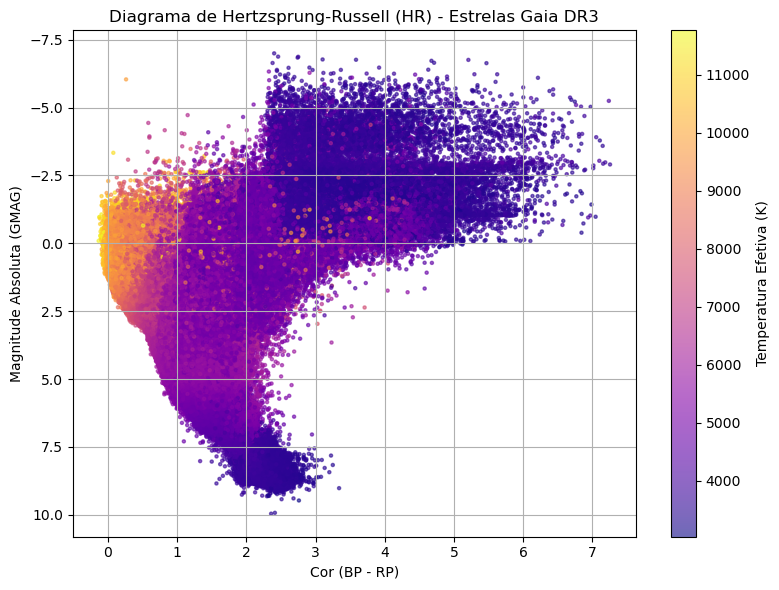

In [20]:
# Cor da Estrela: É a diferenca entre as magnetudes
df_model['Color_BP-RP'] = df_model['BPmag'] - df_model['RPmag']

# Plot do diagrama HR
plt.figure(figsize=(8, 6))
plt.scatter(df_model['Color_BP-RP'], df_model['GMAG'], 
            c=df_model['Teff'], cmap='plasma', s=5, alpha=0.6)

# Inverter o eixo Y, pois magnitudes menores = estrelas mais brilhantes
plt.gca().invert_yaxis()

plt.xlabel('Cor (BP - RP)')
plt.ylabel('Magnitude Absoluta (GMAG)')
plt.title('Diagrama de Hertzsprung-Russell (HR) - Estrelas Gaia DR3')
plt.colorbar(label='Temperatura Efetiva (K)')
plt.grid(True)
plt.tight_layout()
plt.show()

- **Podemos perceber que: as estrelas amarelas (á esquerda) sao as mais quentes e massivas**
- **As estrelas azuis (a direita) tendem a ser as mais frias**
- **E tambem temos estrelas mais brilhantes e menos brinhates**
- **Pode-se notar uma Sequencia Principal onde vivem a maioria das esrelas**


### * Mapa de calor das correlações entre variáveiso 

**A corelacao: mede duas variaveis se relacionam. Varia de -1(inversamente proporcional) até +1 (diretamente propocional).Valres de 0 indicam fraca ou nenhuma correlaçao**

**Nesse ponto o nosso objectivo é saber quais variaveira se relacinam com a idade estelar**

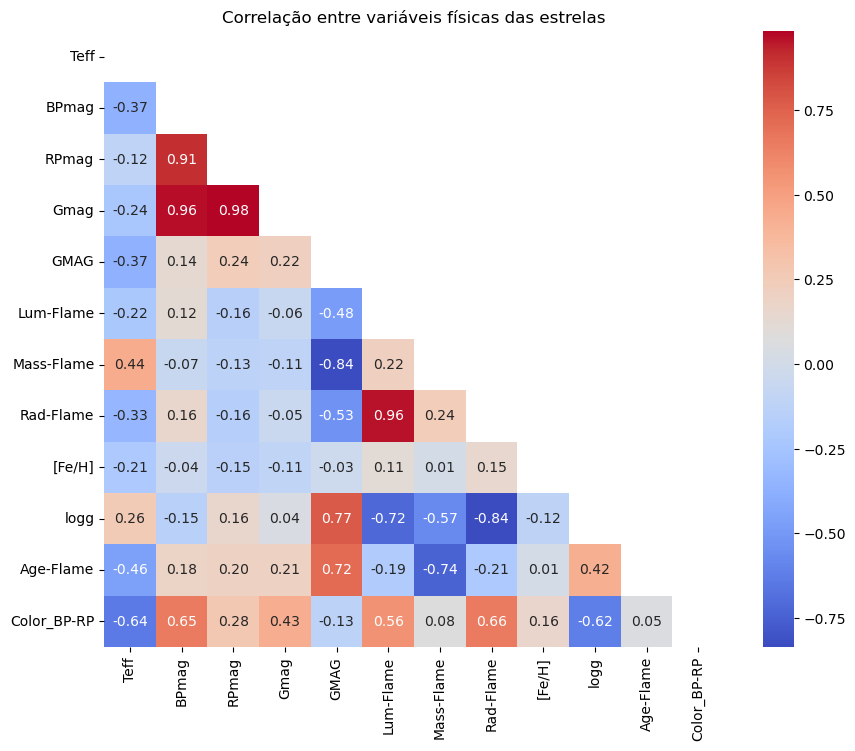

In [21]:
# Matriz de correlação (Pearson)
plt.figure(figsize=(10, 8))
correlacoes = df_model.corr()

# Usamos máscara para não duplicar
mask = np.triu(np.ones_like(correlacoes, dtype=bool))

sns.heatmap(correlacoes, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlação entre variáveis físicas das estrelas")
plt.show()

**Interpretacao do Mapa:**
- Percebe-se que a correlacao mostra que a idade estelar esta fortemente relacionada com a massa( correlacao de  -0.74), indicando que estrelas mais massivas tendem a ser mais jovens, como esperado na Astrofisica.
- A  magnetude absoluta tambem se correlaciona positivamente (=0.74),sugerindo que as estrelas menos brilhantes sao, em media mais velhas.
- A temperatura efetiva apresenta uma correlacao moderada negativa (-0.46), o que reforca que as estrelas mais quentes vivem menos.
- Variaveis como gravidade superficial(logg) tambem mostram boa relacao com com idade (+0.42), enquantp outras como `color_BP_RP` e Metalicidade `[Fe/H]` tem correlacao fraco ou quase nula.
- As melhores variaveis preditora para a idadesao `Massa-Flame`, `GMAG`, `Teff` e `logg`.


### * Idade vs Massa da Estrela (usando o Scatter)

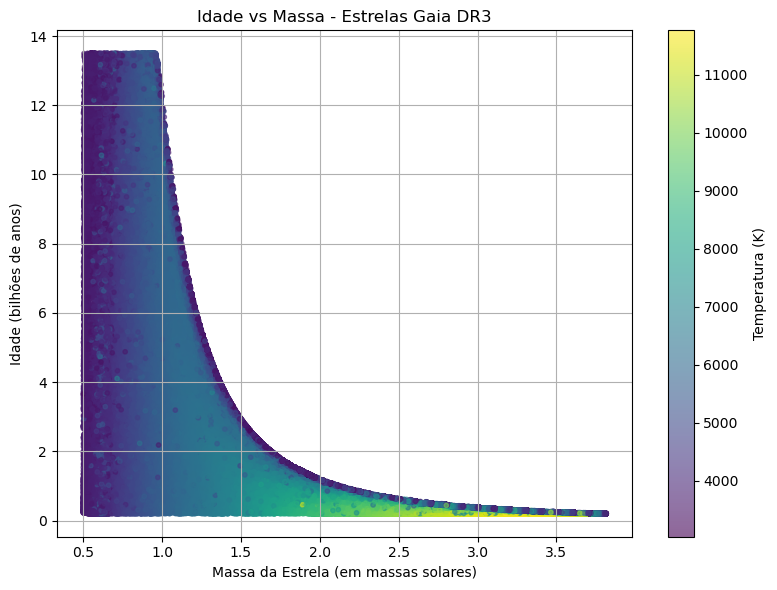

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(df_model['Mass-Flame'], df_model['Age-Flame'], 
            c=df_model['Teff'], cmap='viridis', alpha=0.6, s=10)

plt.xlabel('Massa da Estrela (em massas solares)')
plt.ylabel('Idade (bilhões de anos)')
plt.title('Idade vs Massa - Estrelas Gaia DR3')
plt.colorbar(label='Temperatura (K)')
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretacao:**
- Percebe-se que: as estrelas mais massivas vivem menos tempo, ou seja quanto maior a massa menor sera a idade de vida
- As estrelas de menor massa podem viver por dezenas de bilhoes de anos, ou ate mesmo que a actual idade do nosso universo

### * 3D Scatter Plot: Massa × Luminosidade × Idade

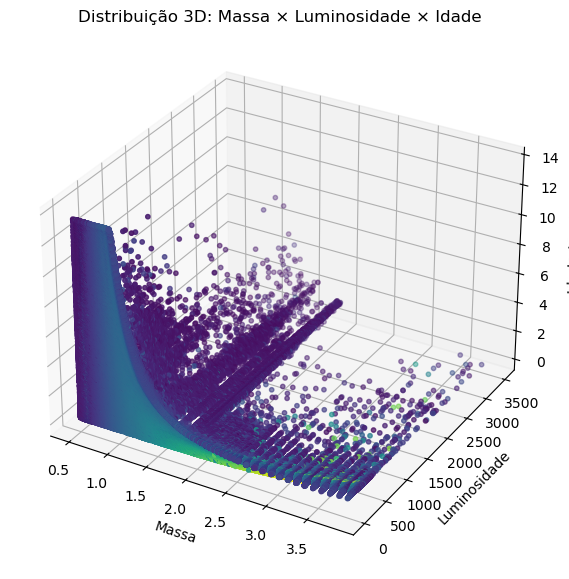

In [34]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_model['Mass-Flame'], df_model['Lum-Flame'], df_model['Age-Flame'],
           c=df_model['Teff'], cmap='viridis', s=10)

ax.set_xlabel('Massa')
ax.set_ylabel('Luminosidade')
ax.set_zlabel('Idade (Gyr)')
plt.title('Distribuição 3D: Massa × Luminosidade × Idade')
plt.show()

**Podemos ver como as estrelas com diferentes massas e brilhos se distribuem em termos de idade**

### *Distribuição da idade estelar

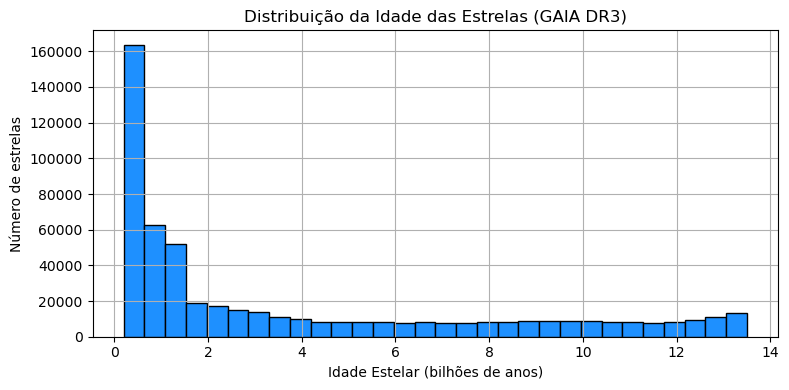

In [25]:
plt.figure(figsize=(8, 4))
plt.hist(df_model['Age-Flame'], bins=30, color='dodgerblue', edgecolor='black')
plt.xlabel('Idade Estelar (bilhões de anos)')
plt.ylabel('Número de estrelas')
plt.title('Distribuição da Idade das Estrelas (GAIA DR3)')
plt.grid(True)
plt.tight_layout()
plt.show()


**Interpretacao**
- A maioria das estrelas temm idades entre 1 e 8 bilhoes de abos luz

In [ ]:
# BoxPlot para detecta outliares da idade das estrelas

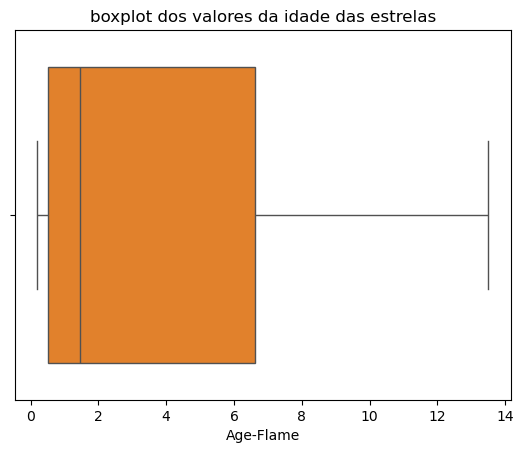

In [10]:
sns.boxplot( x = df_model['Age-Flame'], color = 'C1')
plt.title('boxplot dos valores da idade das estrelas')
plt.show()

**Interpretacao:**
- A mediana da idade esta perto de 2 bilhoes de anos luz
- Nao exitem outlires no dataset

### * Boxplot da idade por faixas de massa

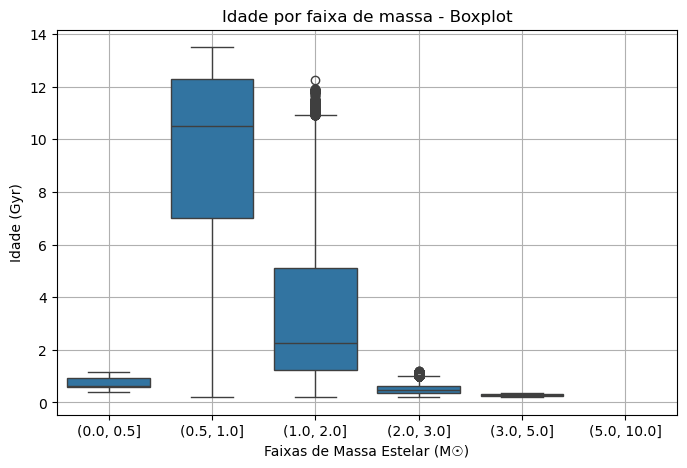

In [12]:
df_model['massa_bin'] = pd.cut(df_model['Mass-Flame'], bins=[0, 0.5, 1, 2, 3, 5, 10])
plt.figure(figsize=(8,5))
sns.boxplot(x='massa_bin', y='Age-Flame', data=df_model)
plt.xlabel("Faixas de Massa Estelar (M☉)")
plt.ylabel("Idade (Gyr)")
plt.title("Idade por faixa de massa - Boxplot")
plt.grid(True)
plt.show()


**Interpretacao:**
- Percebe-se que a idade das estrelas varia fortemente com a massa: estrelas de baixa massa (especialmente entre 0,5 e 1,0 M☉) apresentam ampla variação de idade, alcançando até 13 bilhões de anos, o que reforça que essas estrelas vivem por longos períodos.
- Já estrelas com massas entre 1,0 e 2,0 M☉ são significativamente mais jovens, com idades medianas próximas a 2 bilhões de anos. Estrelas mais massivas (acima de 2 M☉) têm idades muito baixas, confirmando o princípio da astrofísica de que quanto maior a massa, mais curta é a vida da estrela

# Etapa 5: Modeling/Analysis

**Nessa etapa vamos Construir um modelo de computador que aprenda a prever a idade de uma estrela com base nas informações físicas dela, como massa, brilho, temperatura etc**

In [15]:
#Nas estapas anteriores definimos: 
# X_scaled - variáveis de entrada normalizadas# y - idade da estrela (Age-Flame)
# features -lista de colunas de entrada (ex: Mass-Flame, GMAG, Teff, logg, etc.)


**1.Vamos dividir os dados em treino e teste**

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


**2.Vamos treinar doir modelos diferentes (Regressao Linear e Random Forest)**

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Modelo simples
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)  

LinearRegression()

In [13]:
# Modelo mais avançado 
rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Esse modelo nos da resultado final com mais precisao, é bem lento em computadores normais

RandomForestRegressor(n_estimators=10, random_state=42)

**3.Vamos fazer as Previsoes**

Agora pedimos aos modelos que prevejam a idade das estrelas do conjunto de teste — aquelas que ele ainda não viu.

In [16]:
y_pred_lr = lr_model.predict(X_test)  # previsões do modelo linear
y_pred_rf = rf_model.predict(X_test)  # previsões do modelo de floresta

**4.Vamos Avaliar os resultados**

queremos ver o quao bem os modelos acima acertam as idades
* MAE (Erro Absoluto Médio): indica o erro médio em bilhões de anos. Quanto menor, melhor.
* R² (Coeficiente de Determinação): diz quanta parte da variação da idade o modelo conseguiu explicar. Vai de 0 a 1 — quanto mais próximo de 1, melhor.

In [17]:
from sklearn.metrics import mean_absolute_error, r2_score

print("Modelo Linear:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

print("\nRandom Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R²:", r2_score(y_test, y_pred_rf))


Modelo Linear:
MAE: 1.9153120199225542
R²: 0.6135737996102089

Random Forest:
MAE: 0.10023047385620922
R²: 0.9917708827578808


**Interpretacao:**

**A regressão linear é rápida, mas está limitada para esse tipo de dado. A relação entre as variáveis e a idade não é puramente linear, por isso o desempenho foi modesto**

**Random Forest se adaptou muito melhor às relações complexas entre as variáveis (massa, temperatura, brilho), fornecendo previsões extremamente precisas. Esse é o modelo ideal para seu projeto final.**

`Ou seja:`

**O modelo Random Forest superou amplamente a regressão linear, com quase perfeição na explicação da idade estelar (R² = 0.99), e erro médio muito baixo (MAE ≈ 0.10 Gyr),**

C:\Users\Miocha\AppData\Local\Temp\ipykernel_4328\2426189772.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importances, x='Importância', y='Variável',legend=False,  palette='viridis')


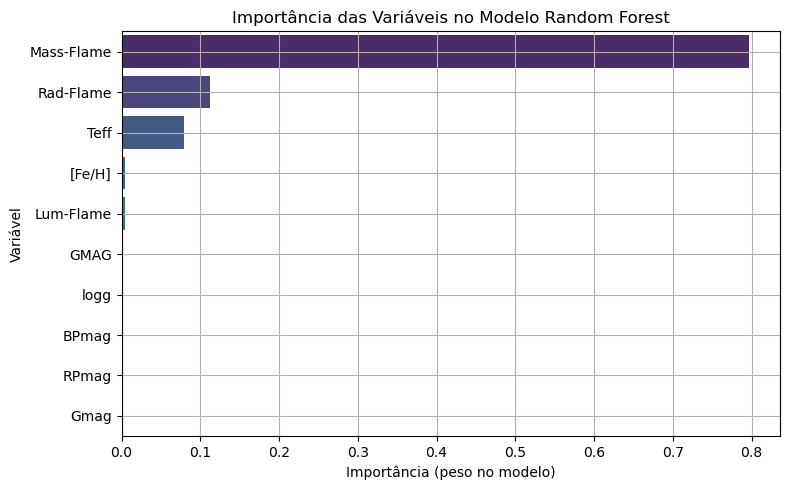

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pegando a importância das variáveis do modelo
importances = rf_model.feature_importances_

# Criando um DataFrame para organizar
feat_importances = pd.DataFrame({'Variável': features, 'Importância': importances})
feat_importances = feat_importances.sort_values(by='Importância', ascending=False)

# Gráfico
plt.figure(figsize=(8,5))
sns.barplot(data=feat_importances, x='Importância', y='Variável',legend=False,  palette='viridis')
plt.title('Importância das Variáveis no Modelo Random Forest')
plt.xlabel('Importância (peso no modelo)')
plt.ylabel('Variável')
plt.grid(True)
plt.tight_layout()
plt.show()


**Interpretacao**

**O modelo identificou a massa estelar como o principal fator físico determinante da idade, com outras variáveis como raio e temperatura contribuindo em menor grau. Isso valida o modelo tanto estatisticamente quanto fisicamente, reforçando o importancia da  massa na evolução das estrelas.**

**5.Visualizando o desempenho do modelo**

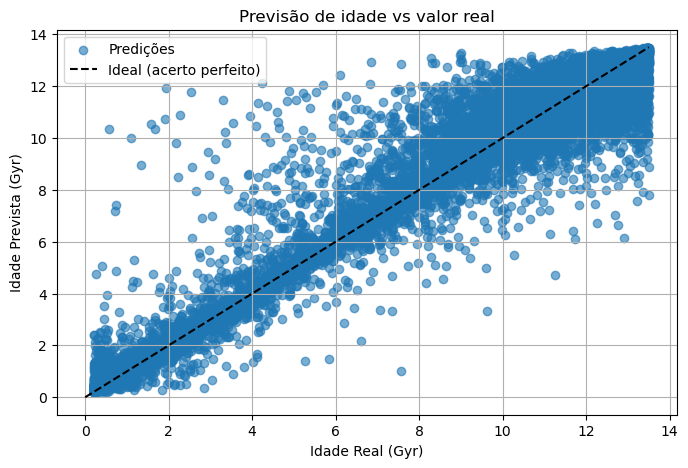

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.6, label='Predições')
plt.plot([0, max(y_test)], [0, max(y_test)], 'k--', label='Ideal (acerto perfeito)')
plt.xlabel("Idade Real (Gyr)")
plt.ylabel("Idade Prevista (Gyr)")
plt.title("Previsão de idade vs valor real")
plt.legend()
plt.grid(True)
plt.show()


**Os modelos estao perto da linha tracejada, isto é, o modelo esta bom.**

# Etapa 6: Results & Interpretation

### Objetivo recapitulativo:
**Prever a idade de estrelas com base em características observacionais e físicas disponíveis no catálogo GAIA,usando técnicas de machine learning.**

### Principais resultados e interpretações:
**A massa da estrela foi a variável mais importante para prever a idade.**

O modelo Random Forest atribuiu a ela mais de 80% de importância, o que reforça um princípio fundamental da astrofísica estelar: estrelas massivas vivem menos tempo , pis consomem rapidamende o seu combutivel

**Modelos não lineares foram significativamente mais eficazes**
- A regressão linear teve desempenho moderado (R² ≈ 0.61), pois não consegue capturar relações complexas
- O Random Forest alcançou R² ≈ 0.99 e MAE ≈ 0.10 Gyr, indicando excelente capacidade preditiva.

**As variáveis menos importantes incluíram luminosidade, metalicidade e magnitudes aparentes, mostrando que, para prever idade, o modelo se apoia principalmente nas variáveis estruturais (massa, raio, temperatura) — ou seja, nos fatores físicos ligados à evolução estelar**

**O modelo mostrou que é possível prever com alta precisão a idade de uma estrela usando apenas dados observacionais, sem depender de isócronas complexas ou modelos evolutivos manuais.**
  


# Conclusion & Future Work

### Conclusion
**Neste projeto, explorou-se a capacidade de modelos de aprendizado de máquina para prever a idade de estrelas a partir de dados físicos extraídos do catálogo GAIA DR3, como massa, temperatura efetiva, luminosidade, magnitude absoluta e gravidade superficial. Após realizar uma limpeza cuidadosa dos dados e análises exploratórias detalhadas, treinamos e avaliamos dois modelos principais: Regressão Linear e Random Forest Regressor**


**Os resultados demonstraram que modelos não lineares (como Random Forest) são altamente eficazes nesse tipo de tarefa, com destaque para o Random Forest, que alcançou precisão quase perfeita (R² ≈ 0.99) e erro médio muito baixo (MAE ≈ 0.10 Gyr).**

**A variável com maior impacto foi a massa estelar, validando um princípio-chave da evolução estelar: quanto maior a massa, menor a expectativa de vida da estrela.**

**Este projeto mostra que é possível construir um modelo rápido, automatizado e confiável para estimar idades estelares com base em observações, sem necessidade de consultar diretamente modelos teóricos complexos.**

### Future Work
- **Usar dados espectrais ou temporais com redes neurais mais complexas (ex:RNN)**
Isso permitiria prever idade com base em espectros estelares ou curvas de luz, expandindo a abordagem para outros tipos de dados astronômicos.

- **Incluir estimativas de incerteza (erro da idade)**
Incorporar as incertezas das variáveis observacionais e modelar a previsão da idade com intervalo de confiança

- **Transformar o modelo em uma ferramenta interativa**
Criar uma aplicação web onde o usuário insere os parâmetros físicos de uma estrela e recebe uma estimativa da sua idade

# References/Data Sources
Dataset GAIA DR3 filtrado via Kaggle

Título: Gaia 626k stars from DR3

Fonte: https://www.kaggle.com/datasets/tanlikesmath/gaia-626k-stars-from-dr3 

Uso: Versão em CSV usada como base local para testes e modelagem, contendo massa, idade, temperatura, magnitudes e mais.

### References
* ESA GAIA Mission Papers: Brown, A.G.A. et al. (2021). Gaia Early Data Release 3. Astronomy & Astrophysics, 649, A1
* Kippenhahn, R., & Weigert, A. (2012). Stellar Structure and Evolution. Springer.
